# Taller 2 

## Integrantes:
- Felipe Villa Jaramillo
- Juan Pablo Cardona Bedoya


## Módulos

In [90]:
import numpy as np
import time

def gauss_seidel_matrices(A, b, x0, tol):
    """
    Implementación del método de Gauss Seidel.
    -----------
    Parámetros
    -----------
    - A: matriz de coeficientes cuadrada
    - b: vector de términos independientes
    - x0: vector inicial --> Si no me da el dato se asume que el vector es el vector nulo
    - tol: Exactitud con la cual encontraremos la solución del sistema de ecuaciones lineales (SEL). Si no me dan este dato se asume que la tolerancia es 1e-6
    -----------
    Nota
    ------------
    - TANTO LA MATRIZ A COMO EL VECTOR b Y X0 TIENEN QUE SER DE TIPO FLOTANTE
    - AMBAS TIENE QUE TENER DIAGONAL ESTRICTAMENTE DOMINANTE
    -------------
    Retorna:
        x0: solución final
        error_final: error de la última iteración
        errores: lista de errores por iteración
        iteraciones: lista de número de iteración (1, 2, ...)
        time_total: tiempo total de ejecución
    """
    D = np.diag(np.diag(A)) # Obtenemos la matriz diagonal
    L = D - np.tril(A) # Obtenemos la matriz inferior
    U = D - np.triu(A) # Obtenemos la matriz superior
    Tg = np.dot(np.linalg.inv(D-L), U)
    Cg = np.dot(np.linalg.inv(D-L), b)
    v_propios, vect_propios = np.linalg.eig(Tg)
    radio = max(abs(v_propios))
    print(f"Radio espectral: {radio}")
    if radio<1:
        import time
        time_start = time.time()
        error = 1
        iteracion = 1
        errores = []
        while (error > tol):
            x1 = np.dot(Tg,x0) + Cg
            error = np.max(np.abs(x1-x0))
            errores.append(error)
            x0 = np.copy(x1)
            iteracion += 1
        time_end = time.time()
        time_total = time_end - time_start
        return x0, error, errores, time_total, iteracion-1
            
    else:
        print("El sistema iterativo no converge con el método de Jacobi")
        return None, None, [], 0, 0

import numpy as np

def gauss_seidel_sumas(A, b, x0=None, tol=1e-10, max_iter=100):
    """
    Método de Gauss-Seidel para resolver Ax = b con suma de cambios por iteración.
    
    Parámetros:
        A : array-like (n x n)
        b : array-like (n)
        x0 : array-like (n), condiciones iniciales (opcional)
        tol : tolerancia para el criterio de parada
        max_iter : número máximo de iteraciones
    
    Retorna:
        x : solución aproximada (array de NumPy)
        error_final : error de la última iteración
        errores : lista con el error por iteración (norma infinito)
        iteraciones : lista de número de iteración (1, 2, ...)
        tiempo_total : tiempo de ejecución
    """
    import time
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    if x0 is None:
        x = np.zeros_like(b, dtype=float)
    else:
        x = np.array(x0, dtype=float)

    suma_iteraciones = []
    errores = []

    time_start = time.time()

    for it in range(1, max_iter+1):
        x_new = x.copy()
        suma_cambios = 0.0

        for i in range(n):
            suma = np.dot(A[i, :i], x_new[:i]) + np.dot(A[i, i+1:], x[i+1:])
            nuevo_valor = (b[i] - suma) / A[i, i]
            suma_cambios += abs(nuevo_valor - x[i])
            x_new[i] = nuevo_valor

        suma_iteraciones.append(suma_cambios)
        error = np.max(np.abs(x_new - x))
        errores.append(error)

        if suma_cambios < tol:
            break

        x = x_new

    time_end = time.time()
    tiempo_total = time_end - time_start
    error_final = errores[-1] if errores else None
    iteraciones = it

    return x, error_final, errores, tiempo_total, iteraciones


def jacobi_con_matrices(A,b,x0,tol):
    """
    Implementación del método de Jacobi utilizando matrices.
    -----------
    Parámetros
    -----------
    - A: matriz de coeficientes cuadrada
    - b: vector de términos independientes
    - x0: vector inicial --> Si no me da el dato se asume que el vector es el vector nulo
    - tol: Exactitud con la cual encontraremos la solución del sistema de ecuaciones lineales (SEL). Si no me dan este dato se asume que la tolerancia es 1e-6
    -----------
    Nota
    ------------
    - TANTO LA MATRIZ A COMO EL VECTOR b Y X0 TIENEN QUE SER DE TIPO FLOTANTE
    - AMBAS TIENE QUE TENER DIAGONAL ESTRICTAMENTE DOMINANTE
    """
    D = np.diag(np.diag(A)) # Obtenemos la matriz diagonal
    L = D - np.tril(A) # Obtenemos la matriz inferior
    U = D - np.triu(A) # Obtenemos la matriz superior
    Tj = np.dot(np.linalg.inv(D), L+U)
    Cj = np.dot(np.linalg.inv(D), b)
    v_propios, vect_propios = np.linalg.eig(Tj)
    radio = max(abs(v_propios))
    print(radio)
    if radio<1:
        time_start = time.time()
        error = 1
        iteracion = 1
        errores = []
        while (error > tol):
            x1 = np.dot(Tj,x0) + Cj
            error = np.max(np.abs(x1-x0))
            errores.append(error)
            x0 = np.copy(x1)
            # print(f"Iteración {iteracion}: {x1}, Error: {error}")
            iteracion += 1
        time_end = time.time()
        time_total = time_end - time_start
        return x0, error, errores, time_total, iteracion
            
    else:
        print("El sistema iterativo no converge con el método de Jacobi")

def jacobi_con_sumas(A, b, x0, n_max, tol):
    """
    -----------
    Parametros
    -----------
    - A: matriz de coeficientes cuadrada
    - b: vector de términos independientes
    - x0: vector inicial --> Si no me da el dato se asume que el vector es el vector nulo
    - n_max: número máximo de iteraciones
    - tol: Exactitud con la cual encontraremos la solución del sistema de ecuaciones lineales (SEL). Si no me dan este dato se asume que la tolerancia es 1e-6
    -----------
    Nota
    ------------
    - TANTO LA MATRIZ A COMO EL VECTOR b Y X0 TIENEN QUE SER DE TIPO FLOTANTE
    - AMBAS TIENE QUE TENER DIAGONAL ESTRICTAMENTE DOMINANTE
    """

    n = len(b)  # -> Tamaño del vector b que es el mismo de A porque es cuadrada
    x1 = np.zeros(n)
    error = 10
    iteracion = 0
    errores = []
    
    
    time_start = time.time()
    while error > tol and iteracion < n_max:
        for i in range(n):
            suma = 0  # Inicializar suma para cada fila
            for j in range(n):
                if i != j:
                    suma += np.dot(A[i][j], x0[j])  # Acumular la suma correctamente
            x1[i] = (b[i] - suma) / A[i][i]
        
        # Calculo el error como la norma infinito de la diferencia
        error = np.max(np.abs(x1 - x0))
        errores.append(error)
        
        # Actualizo el vector inicial
        x0 = np.copy(x1)
        iteracion += 1
        
        # print(f"Iteración {iteracion}: {x1}, Error: {error}")
    time_end = time.time()
    tiempo_total = time_end - time_start
    
    return x1, error, errores, tiempo_total, iteracion

import numpy as np

def minimos_cuadrados(x, y):
    """
    Ajuste de mínimos cuadrados para una función lineal.
    
    Parameters:
    x (array-like): Valores de la variable independiente.
    y (array-like): Valores de la variable dependiente.
    
    Returns:
    tuple: Coeficientes del polinomio ajustado (a0, a1).
    """
    Sx = np.sum(x)
    Sy = np.sum(y)
    Sx2 = np.sum(x**2)
    Sxy = np.sum(x*y)
    n = len(x) # numero de datoso

    a0 = ((Sy * Sx2) - (Sx * Sxy)) / ((n * Sx2) - (Sx)**2)
    a1 = ((n * Sxy) - (Sx * Sy)) / ((n * Sx2) - (Sx)**2)

    return a0, a1

import numpy as np

def metodo_euler_profe(f,a,b,h,y0):
    """
    Parameters
    ----------
    f : function
        Ecuación diferencial a aproximar.
    a : float
        Valor del intervalo en a.
    b : float
        Valor del intervalo en b.
    h : float
        Esparcimiento.
    y0 : list
        Condiciones iniciales de la ecuación diferencial.
    Returns
    -------
    tiempos : numpy.ndarray
        Arreglo de tiempos discretizados.
    weu : list
        Aproximación de la ecuación diferencial por el método de Euler.
    """
    weu = [y0]
    n = int((b-a)/h)
    for i in range(n):
        weu.append(weu[i] + h*f(a + i*h,weu[i]))
    return np.linspace(a,b,n+1),weu

def runge_kutta(f,a,b,h,y0):
    n = int((b-a)/h)
    wrk=[y0]
    for i in range(n):
        k1= h*f(a+i*h, wrk[i])
        k2= h*f(a+i*h+0.5*h, wrk[i]+0.5*k1)
        k3= h*f(a+i*h+0.5*h, wrk[i]+0.5*k2)
        k4= h*f(a+(i+1)*h, wrk[i]+k3)
        wrk.append(wrk[i]+(1/6)*(k1+2*k2+2*k3+k4))
    return np.linspace(a,b,n+1),wrk

import sympy as sp

def lagrange_pol(x_data, y_data):
    x = sp.symbols('x')
    
    P = 0 # Acumulador del polinomio
    n = len(x_data) # Número de datos
    
    for i in range(n):
        Li = 1
        for j in range(n):
            if j != i:
                Li *= (x - x_data[j]) / (x_data[i] - x_data[j])
        P += Li * y_data[i]
    return sp.expand(P)

import numpy as np
import matplotlib.pyplot as plt


def graficar_escalas(x_d, y_d):
    """
    Función que grafica los datos en escalas diferentes escalas.

    Parámetros
    ----------
    x_d : array
        Datos en el eje x.
    y_d : array
        Datos en el eje y.
    Returns
    -------
    graficas : list
        Lista de graficas generadas.
        
    """
    plt.figure(figsize=(12, 12), dpi=100)
    plt.subplot(331)
    plt.plot(x_d , y_d, 'or', label='Datos observados') # graficos de dispersión
    plt.subplot(332)
    plt.plot(x_d, np.sqrt(y_d), 'ob')
    plt.xlabel('x')
    plt.ylabel('$\sqrt{y}$')
    plt.subplot(333)
    plt.plot(x_d, 1/y_d, 'ob')
    plt.xlabel('x')
    plt.ylabel('$1/y$')
    plt.subplot(334)
    plt.plot(x_d**2, y_d, 'ob')
    plt.xlabel('$x^2$')
    plt.ylabel('y')
    plt.subplot(335)
    plt.plot(x_d**3, y_d, 'ob')
    plt.xlabel('$x^3$')
    plt.ylabel('y')
    plt.subplot(336)
    plt.plot(np.log(x_d), y_d, 'ob')
    plt.xlabel('$\log(x)$')
    plt.ylabel('y')
    plt.subplot(337)
    plt.plot(x_d, np.log(y_d), 'ob')
    plt.ylabel('$\log(y)$')
    plt.xlabel('x')
    plt.subplot(338)
    plt.plot(np.sqrt(x_d), y_d, 'ob')
    plt.xlabel('$\sqrt{x}$')
    plt.ylabel('y')
    plt.subplot(339)
    plt.plot(np.log(x_d), np.log(y_d), 'ob')
    plt.xlabel('$\log(x)$')
    plt.ylabel('$\log(y)$')
    plt.subplots_adjust(wspace=0.4, hspace=0.6)  # Ajusta el espacio entre subgráficos
    return plt

<>:313: SyntaxWarning: invalid escape sequence '\s'
<>:328: SyntaxWarning: invalid escape sequence '\l'
<>:332: SyntaxWarning: invalid escape sequence '\l'
<>:336: SyntaxWarning: invalid escape sequence '\s'
<>:340: SyntaxWarning: invalid escape sequence '\l'
<>:341: SyntaxWarning: invalid escape sequence '\l'
<>:313: SyntaxWarning: invalid escape sequence '\s'
<>:328: SyntaxWarning: invalid escape sequence '\l'
<>:332: SyntaxWarning: invalid escape sequence '\l'
<>:336: SyntaxWarning: invalid escape sequence '\s'
<>:340: SyntaxWarning: invalid escape sequence '\l'
<>:341: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_33910/31504852.py:313: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{y}$')
/tmp/ipykernel_33910/31504852.py:328: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log(x)$')
/tmp/ipykernel_33910/31504852.py:332: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log(y)$')
/tmp/ipykernel_33910/31504852.py:336: SyntaxWarning

## Ejercicios

1. La distribución de temperatura de estado estable en una placa caliente está modeladas por la ecuación de LaPlace:

$$
0 = \frac{\partial^{2}T}{\partial x^{2}}
$$
Si se representa la placa por una serie de nodos, las diferencias finitas divididas se pueden sustituir por las segundas derivadas, lo que da como resultado un sistema de ecuaciones algebraicas lineales.

![gráfica](https://i.gyazo.com/3dcbac42ab97ef9c52f128a736237fb4.png)

- a) Utilice el método de Gauss-Seidel matrices para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- b) Utilice el método de Gauss-Seidel sumas para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- c) Utilice el método de Jacobi sumas para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- d ) Utilice el método de Jacobi matrices para resolver cuáles son las temperaturas de los nodos que se aprecian en la figura.
- e) Calcule el tiempo de cómputo de cada sistema y grafique los errores( es decir xgs con xgm y xjs con xjm ) y saque conclusiones

Como podemos utilizar laplace para aproximar de forma discreta $T_{i,j}=\frac{1}{4}(T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1})$ entonces podemos saber que en un nodo la temperatura es el promedio de sus 4 vecinos.

- Entonces para $T_{11}$ los vecinos son:

    - Arriba: $T_{12}$
    - Derecha: $T_{21}$
    - Izquierda: 100
    - Abajo: 75

    Entonces la ecuación queda de esta forma:
    $$T_{11} = \frac{1}{4}(T_{12} + T_{21} + 175)$$
    - Despejando:
    $$4T_{11} - T_{12} - T_{21} = 175$$

- Entonces para $T_{12}$ los vecinos son:

    - Arriba: 25
    - Derecha: $T_{22}$
    - Izquierda: 100
    - Abajo: $T_{11}$

    - Entonces la ecuación queda de esta forma:
    $$T_{12} = \frac{1}{4}(T_{11} + T_{22} + 125)$$
    - Despejando:
    $$4T_{12} - T_{11} - T_{22}= 125$$

- Entonces para $T_{21}$ los vecinos son:

    - Arriba: $T_{22}$
    - Derecha: 0
    - Izquierda: $T_{11}$
    - Abajo: 75

    - Entonces la ecuación queda de esta forma:
    $$T_{21} = \frac{1}{4}(T_{11} + T_{22} + 75)$$
    - Despejando:
    $$4T_{21} - T_{11} - T_{22} = 75$$

- Entonces para $T_{22}$ los vecinos son:

    - Arriba: 25
    - Derecha: 0
    - Izquierda: $T_{12}$
    - Abajo: $T_{21}$

    - Entonces la ecuación queda de esta forma:
    $$T_{22} = \frac{1}{4}(T_{12} + T_{21} + 25)$$
    - Despejando:
    $$4T_{22} - T_{12} - T_{21}=25$$

Con lo anterior ya podemos empezar a resolver cada item

## Item (a)

In [91]:
import numpy as np

A = np.array([[4, -1, -1, 0],
              [-1, 4, 0, -1],
              [-1, 0, 4, -1],
              [0, -1, -1, 4]], dtype=float)

b = np.array([175, 125, 75, 25], dtype=float)
x0 = np.zeros_like(b)

sol_gauss_seidel_matrices = gauss_seidel_matrices(A, b, x0, 1e-6)
print("Gauss Seidel con matrices:", sol_gauss_seidel_matrices)

Radio espectral: 0.24999999999999997
Gauss Seidel con matrices: (array([68.7499999 , 56.24999995, 43.74999995, 31.24999997]), np.float64(3.14321368932724e-07), [np.float64(43.75), np.float64(17.96875), np.float64(5.2734375), np.float64(1.318359375), np.float64(0.32958984375), np.float64(0.0823974609375), np.float64(0.020599365234375), np.float64(0.00514984130859375), np.float64(0.0012874603271484375), np.float64(0.0003218650817871094), np.float64(8.046627044677734e-05), np.float64(2.0116567611694336e-05), np.float64(5.029141902923584e-06), np.float64(1.257285475730896e-06), np.float64(3.14321368932724e-07)], 0.0006170272827148438, 15)


## Item (b)

In [92]:

sol_gauss_seidel_sumas = gauss_seidel_sumas(A, b, x0, 1e-6)
print("Gauss Seidel con sumas:", sol_gauss_seidel_sumas)

Gauss Seidel con sumas: (array([68.74999958, 56.24999979, 43.74999979, 31.2499999 ]), np.float64(3.14321368932724e-07), [np.float64(43.75), np.float64(17.96875), np.float64(5.2734375), np.float64(1.318359375), np.float64(0.32958984375), np.float64(0.0823974609375), np.float64(0.020599365234375), np.float64(0.00514984130859375), np.float64(0.0012874603271484375), np.float64(0.0003218650817871094), np.float64(8.046627044677734e-05), np.float64(2.0116567611694336e-05), np.float64(5.029141902923584e-06), np.float64(1.257285475730896e-06), np.float64(3.14321368932724e-07)], 0.003934144973754883, 15)


## Item(c)

In [93]:

sol_jacobi_con_sumas = jacobi_con_sumas(A, b, x0, 1000, 1e-6)
print("Jacobi con sumas:", sol_jacobi_con_sumas)

Jacobi con sumas: (array([68.74999925, 56.24999925, 43.74999925, 31.24999925]), np.float64(7.450580596923828e-07), [np.float64(43.75), np.float64(12.5), np.float64(6.25), np.float64(3.125), np.float64(1.5625), np.float64(0.78125), np.float64(0.390625), np.float64(0.1953125), np.float64(0.09765625), np.float64(0.048828125), np.float64(0.0244140625), np.float64(0.01220703125), np.float64(0.006103515625), np.float64(0.0030517578125), np.float64(0.00152587890625), np.float64(0.000762939453125), np.float64(0.0003814697265625), np.float64(0.00019073486328125), np.float64(9.5367431640625e-05), np.float64(4.76837158203125e-05), np.float64(2.384185791015625e-05), np.float64(1.1920928955078125e-05), np.float64(5.9604644775390625e-06), np.float64(2.9802322387695312e-06), np.float64(1.4901161193847656e-06), np.float64(7.450580596923828e-07)], 0.004490852355957031, 26)


## Item(d)

In [94]:

sol_jacobi_con_matrices = jacobi_con_matrices(A, b, x0, 1e-6)
print("Jacobi con matrices:", sol_jacobi_con_matrices)

0.5
Jacobi con matrices: (array([68.74999925, 56.24999925, 43.74999925, 31.24999925]), np.float64(7.450580596923828e-07), [np.float64(43.75), np.float64(12.5), np.float64(6.25), np.float64(3.125), np.float64(1.5625), np.float64(0.78125), np.float64(0.390625), np.float64(0.1953125), np.float64(0.09765625), np.float64(0.048828125), np.float64(0.0244140625), np.float64(0.01220703125), np.float64(0.006103515625), np.float64(0.0030517578125), np.float64(0.00152587890625), np.float64(0.000762939453125), np.float64(0.0003814697265625), np.float64(0.00019073486328125), np.float64(9.5367431640625e-05), np.float64(4.76837158203125e-05), np.float64(2.384185791015625e-05), np.float64(1.1920928955078125e-05), np.float64(5.9604644775390625e-06), np.float64(2.9802322387695312e-06), np.float64(1.4901161193847656e-06), np.float64(7.450580596923828e-07)], 0.0016677379608154297, 27)


De lo anterior obtuvimos los siguientes valores **aproximados**:

- $T_{11} = 68.75$
- $T_{12} = 56.25$
- $T_{21} = 43.75$
- $T_{22} = 31.25$

Que son coherentes en todos los métodos  que utilizamos


## Item(e)

En los códigos anteriores también obtuvimos el tiempo pero acá vamos a hacer el análisis concreto

Errores entre Gauss Seidel con matrices y sumas: [3.14321369e-07 1.57160684e-07 1.57160684e-07 7.85803422e-08]
Errores entre Jacobi con matrices y sumas: [0. 0. 0. 0.]


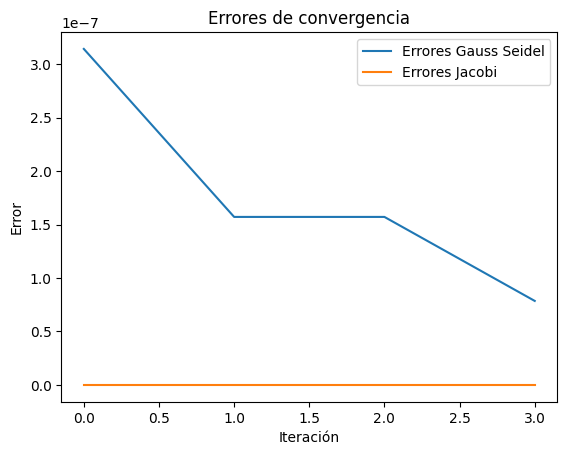

In [95]:
import matplotlib.pyplot as plt

errores_guass_seidel = np.abs(sol_gauss_seidel_matrices[0] - sol_gauss_seidel_sumas[0])
print("Errores entre Gauss Seidel con matrices y sumas:", errores_guass_seidel)
errores_jacobi = np.abs(sol_jacobi_con_matrices[0] - sol_jacobi_con_sumas[0])
print("Errores entre Jacobi con matrices y sumas:", errores_jacobi)

plt.plot(errores_guass_seidel, label='Errores Gauss Seidel')
plt.plot(errores_jacobi, label='Errores Jacobi')
plt.xlabel('Iteración')
plt.ylabel('Error')
plt.title('Errores de convergencia')
plt.legend()

### Conclusiones

De acá nos dimos cuenta que:
- Gauss seidel converge muchísimo más rápido
- Todos los métodos están bien implementados ya que convergen a la misma aproximación
- La diferencia de tiempo es notable en los métodos matriciales ya que son más rápidos y esto los hace más eficientes

## 2.
Un péndulo cuelga de un soporte que se desliza como se ilustra en la figura. 

![Gráfica ejercicio](https://i.gyazo.com/ad981e4db8fee1f35a8df33f9c1673c2.png)

Inicialmente, en el tiempo $t = 0$, se aplica un movimiento oscilatorio $y(t) = Y sen(ωt)$ sobre el soporte. La ecuación diferencial que describe el movimiento del péndulo es:

$$\theta'' =- \frac{g}{L} sen(\theta) + \frac{ω^{2}}{L}Y cos(\theta)sen(ωt)$$

Grafique θ vs t desde $t = 0$ hasta $t = 10$ s y determine el valor más grande de θ durante este perı́odo. Utilice $g = 9.80665 \frac{m}{s^2}$ , $L = 1.0m$, $Y = 0.25m$ y $ω = 2.5 rad/s$ con $θ(0) = \frac{π}{6}$ y $θ′ (0) = 0$

Para resolver este ejercicio lo que primero vamos a hacer es bajarle un grado a la ecuación diferencial para poder aplicarle range-kutta.

Definimos un cambio de variable el cual es el siguiente:
- $\theta = y_1$
- $\theta' = y_2$

Ahora reemplaazmos en la ecuación original:
$$y_2' = \theta''$$

$$y_2' =- \frac{g}{L} sen(y_1) + \frac{ω^{2}}{L}Y cos(y_1)sen(ωt)$$

ENtonces el sistema de ecuaciones nos queda de esta manera:

$$
\begin{cases}
y_1' = y_2 \\
y_2' = -\frac{g}{L} sen(y_1) + \frac{\omega^2}{L} Y cos(y_1) \sin(\omega t)
\end{cases}
$$

De esta manera ya le podemos dar solución por el método de Range-kutta

[[ 0.52359878  0.        ]
 [ 0.52359632 -0.00490163]
 [ 0.52358897 -0.00979983]
 ...
 [ 0.39180406  2.67936864]
 [ 0.39448145  2.67541539]
 [ 0.39715488  2.67144171]]


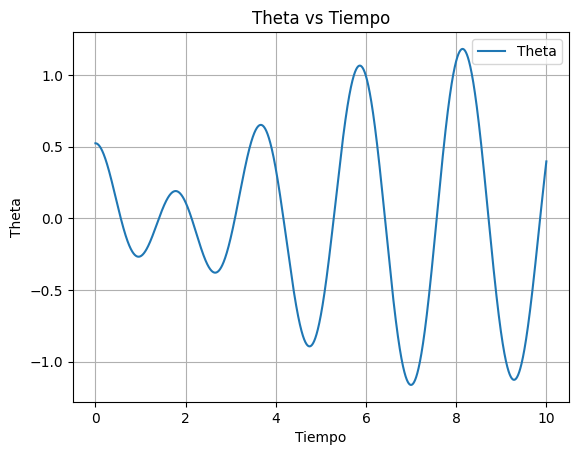

In [96]:
import numpy as np
import matplotlib.pyplot as plt

def func(t, y):
    g =9.80665
    L =1
    Y = 0.25
    w = 2.5

    y1 =y[0]
    y2 =y[1]

    y1_prima = y2
    y2_prima = - (g / L) * np.sin(y1) + (w**2 / L) * Y * np.cos(y1) * np.sin(w * t)

    return np.array([y1_prima, y2_prima])

tiempos_runge_kutta, modelo_runge_kutta = runge_kutta(func, 0, 10, 0.001,[np.pi/6, 0])
modelo_runge_kutta = np.array(modelo_runge_kutta)
print(modelo_runge_kutta)
theta = (modelo_runge_kutta[:, 0])
theta_prima = (modelo_runge_kutta[:, 1])

plt.plot(tiempos_runge_kutta, theta, label='Theta')
plt.xlabel('Tiempo')
plt.ylabel('Theta')
plt.title('Theta vs Tiempo')
plt.legend()
plt.grid()
plt.show()




El valor máximo de $\theta$ es el siguiente

In [97]:
theta_max = max(theta)
print("El valor máximo de theta:", theta_max)

El valor máximo de theta: 1.1817750979571513


## 3.
 Dinámica de Burbuja-Litotricia: La litotricia es una técnica utilizada para destruir los cálculos que se forman en el riñón, la vejiga, los uréteres o la vesı́cula biliar. Hay varias formas de hacerla, aunque la más común es la litotricia extracorpórea (por fuera del cuerpo) por ondas de choque. Las ondas de choque se concentran en los cálculos y los rompen en fragmentos diminutos que luego salen del cuerpo en forma natural durante la micción. Los pulsos litotricios inducen cavitación, y las oscilaciones en los radios de las burbujas resultantes juegan un papel importante en la fragmentación de los cálculos. Howle, Schaeffer, Shearer, y Zhong (“Lithotripsy: The Treatment of Kidney Stone with Shock Waves”, SIAM Review, pp. 356-371, 1998) investigaron las vibraciones libres de esas cavitaciones que inducen burbujas de aire. El modelo que ellos consideran es una problema de valor inicial de segundo orden

$$
RR'' + \frac{3}{2}(R')^2 = a^2 [(\frac{R_o}{R})^{3 \gamma} - 1]
$$

$$R(0) = AR_o  ;  R'(0) = 0$$

donde los puntos denotan diferenciación con respecto al tiempo. R es la variación del radio de la burbuja de aire en el tempo, $R_o = 3 x 10^{-6}m$ es el radio de equilibrio de la burbuja, $\gamma = 1.4$ es el exponente adiabático, y $a = 10 \frac{m}{s}$

- a) Convierta el problema de valores iniciales en un sistema de ecuaciones diferenciales de primer orden.

- b) Solucione numéricamente el sistema de ecuaciones usando el método de Euler con $A = 2.5$ y $R_o = 1$

- c) Solucione numéricamente el sistema de ecuaciones usando el método de Rk4 con $A = 2.5$ y $R_o = 1$

- d) Grafique $R(t)$ vs $t$, $R'(t)$ vs $t$, $R(t)$ vs $R'(t)$

- e) ¿Cómo es la dinámica de la burbuja?, ¿Cómoǘaría el radio de la burbuja de aire con respecto al tiempo?, ¿cuál es el periodo (en segundos) de las oscialciones del radio?

## Item(a)

Primero vamos a redefinidir las siguientes variables:
- $y_1 = R$
- $y_2 = R'$

En donde :

- $y_1$: es el radio
- $y_2$: es la velocidad con la cambia el radio

Luego vamos a reemplazar estas variables en la ecuación original

$$
y_1 y_2' + \frac{3}{2}(y_2)^2 = a^2 [(\frac{R_o}{y_1})^{3 \gamma} - 1]
$$

Ahora despejamos a $y_2$:

$$
y_2' = \frac{a^2[(\frac{R_o}{y_1})^{3 \gamma} - 1] - \frac{3}{2}(y_2)^2}{y_1}
$$

Con todo lo anterior ya podemos armar un sistema ya que $y_1' = y_2$ 

## Item(b)

In [98]:
import numpy as np


def func(t, y ):
    """
    y1 = R
    y2 = R'
    """
    a = 10
    gamma = 1.5
    Ro = 1
    A = 2.5

    y1 = y[0]
    y2 = y[1]

    y1_prima = y2
    y2_prima =((a**2)*((Ro/y1)**(3*gamma)-1)-(3/2)*y2**2)/y1
    
    return np.array([y1_prima, y2_prima])


tiempos_euler, modelo_euler = metodo_euler_profe(func, 0, 1, 0.0001, [2.5, 0])
print(modelo_euler)
R_euler = np.array(modelo_euler)[:,0]
R_prima_euler = np.array(modelo_euler)[:,1]


[[2.5, 0], array([ 2.5       , -0.00393524]), array([ 2.49999961, -0.00787047]), array([ 2.49999882, -0.01180571]), array([ 2.49999764, -0.01574096]), array([ 2.49999606, -0.01967622]), array([ 2.4999941 , -0.02361148]), array([ 2.49999174, -0.02754676]), array([ 2.49998898, -0.03148205]), array([ 2.49998583, -0.03541737]), array([ 2.49998229, -0.0393527 ]), array([ 2.49997836, -0.04328805]), array([ 2.49997403, -0.04722343]), array([ 2.4999693 , -0.05115884]), array([ 2.49996419, -0.05509428]), array([ 2.49995868, -0.05902975]), array([ 2.49995278, -0.06296526]), array([ 2.49994648, -0.0669008 ]), array([ 2.49993979, -0.07083638]), array([ 2.49993271, -0.07477201]), array([ 2.49992523, -0.07870768]), array([ 2.49991736, -0.0826434 ]), array([ 2.49990909, -0.08657916]), array([ 2.49990044, -0.09051498]), array([ 2.49989138, -0.09445086]), array([ 2.49988194, -0.09838679]), array([ 2.4998721 , -0.10232278]), array([ 2.49986187, -0.10625883]), array([ 2.49985124, -0.11019494]), array([ 2

## Item(c)

In [99]:
import numpy as np


def func(t, y ):
    """
    y1 = R
    y2 = R'
    """
    a = 10
    gamma = 1.5
    Ro = 1
    A = 2.5

    y1 = y[0]
    y2 = y[1]

    y1_prima = y2
    y2_prima = (a**2 * ((Ro/y1)**(3*gamma) - 1) - (3/2)*y2**2) / y1
    return np.array([y1_prima, y2_prima])


tiempos_runge_kutta, modelo_runge_kutta = runge_kutta(func, 0, 1, 0.0001, [2.5, 0])
print(modelo_runge_kutta)
R_runge_kutta = np.array(modelo_runge_kutta)[:,0]
R_prima_runge_kutta = np.array(modelo_runge_kutta)[:,1]

[[2.5, 0], array([ 2.4999998 , -0.00393524]), array([ 2.49999921, -0.00787048]), array([ 2.49999823, -0.01180572]), array([ 2.49999685, -0.01574097]), array([ 2.49999508, -0.01967623]), array([ 2.49999292, -0.02361151]), array([ 2.49999036, -0.02754679]), array([ 2.49998741, -0.0314821 ]), array([ 2.49998406, -0.03541742]), array([ 2.49998032, -0.03935277]), array([ 2.49997619, -0.04328814]), array([ 2.49997167, -0.04722354]), array([ 2.49996675, -0.05115897]), array([ 2.49996143, -0.05509442]), array([ 2.49995573, -0.05902992]), array([ 2.49994963, -0.06296545]), array([ 2.49994313, -0.06690101]), array([ 2.49993625, -0.07083662]), array([ 2.49992897, -0.07477227]), array([ 2.49992129, -0.07870797]), array([ 2.49991323, -0.08264372]), array([ 2.49990476, -0.08657952]), array([ 2.49989591, -0.09051537]), array([ 2.49988666, -0.09445128]), array([ 2.49987702, -0.09838725]), array([ 2.49986698, -0.10232327]), array([ 2.49985656, -0.10625937]), array([ 2.49984573, -0.11019552]), array([ 2

## Item(d)

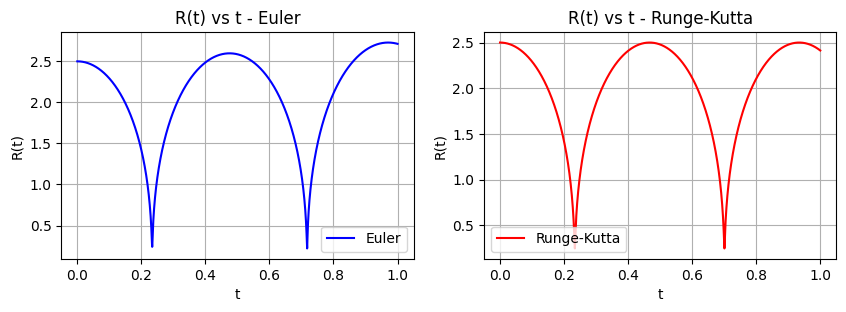

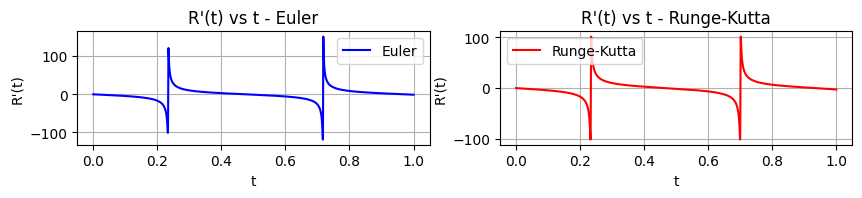

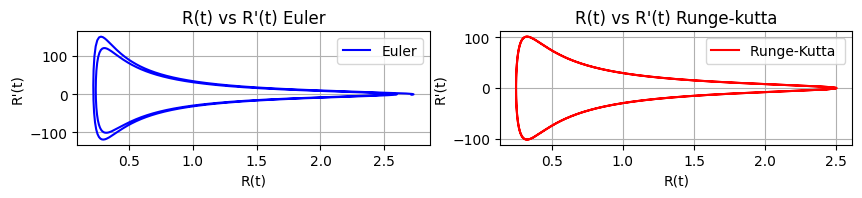

In [100]:
import matplotlib.pyplot as plt
# R vs t
plt.figure(figsize=(10, 10))
plt.subplot(321)
plt.plot(tiempos_euler, R_euler, label="Euler", color='blue')
plt.title("R(t) vs t - Euler")
plt.xlabel("t")
plt.ylabel("R(t)")
plt.legend()
plt.grid()
plt.subplot(322)
plt.plot(tiempos_runge_kutta, R_runge_kutta, label="Runge-Kutta", color='red')
plt.title("R(t) vs t - Runge-Kutta")
plt.xlabel("t")
plt.ylabel("R(t)")
plt.legend()
plt.grid()
# R' vs t
plt.figure(figsize=(10, 5))
plt.subplot(323)
plt.plot(tiempos_euler, R_prima_euler, label="Euler", color='blue')
plt.title("R'(t) vs t - Euler")
plt.xlabel("t")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()
plt.subplot(324)
plt.plot(tiempos_runge_kutta, R_prima_runge_kutta, label="Runge-Kutta", color='red')
plt.title("R'(t) vs t - Runge-Kutta")
plt.xlabel("t")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()

# R vs R'
plt.figure(figsize=(10, 5))
plt.subplot(325)
plt.plot(R_euler, R_prima_euler, label="Euler", color='blue')
plt.title("R(t) vs R'(t) Euler")
plt.xlabel("R(t)")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()
plt.subplot(326)
plt.plot(R_runge_kutta, R_prima_runge_kutta, label="Runge-Kutta ", color='red')
plt.title("R(t) vs R'(t) Runge-kutta")
plt.xlabel("R(t)")
plt.ylabel("R'(t)")
plt.legend()
plt.grid()


## Item(e)

Inicialmente vemos que el radio de la burbuja baja drásticamente y esto pues tiene sentido porque partimos de que la burbuja era más grande por el Ro que nos dieron, después esta epieza a oscilar y que básicamente después del colapso inicial el radio sube y baja en patrón recurrente; Por otro lado el comportamiento es oscilatorio y a pesar de que no son figuras senoidales perfectas se ve que sí se repite en el tiempo, esto hace que la burbuja se contraiga e exapanda en periodos. Esto en las gráficas lo vemos evidenciado en que la velocidad cambia de forma oscilante, variando entre positivo y negativo mientras se expande y contrae.
Por las gráficas pudimos identificar que el periodo es aproximadamente 0.5 segundos

## Conclusiones

- La burbuja oscila alrededor de su radio de equilibrio ($R_o$)
- La amplitud de oscilación decrece con el tiempo (disipación de energía)
- El período depende de los parámetros físicos ($a$, $\gamma$, $R_o$)
- El diagrama de fase muestra una espiral que converge al punto de equilibrio

## 4.

Un biólogo midió la longitud de un esturión por un periodo de 21 años. La tabla muestra el conjunto de datos resultantes donde la longitud $L$ se encuentra en cm y el tiempo en años.

- a) Usé interpolación polinomial simple para determinar la longitud de un esturión en un tiempo de 20.5 años.
- b) Use aproximación a un solo término y construya un modelo no lineal para predecir la longitud de un esturión en un tiempo de 20.5 años.

![tabla](https://i.gyazo.com/5a6f2fe51b56119e730d175a942f682a.png)

In [101]:
import numpy as np

def Matrix(Px):
    """
    Genera la matriz de coeficientes para dar solución.
    ----------
    Parametros:
    -----------
    Px : array
        Vector de puntos x
    Retorna:
    --------
    A : array
        Matriz de coeficientes
    ----------
    """
    n = len(Px)

    A = np.zeros([n, n])
    for i in range(n):
        A[i, 0] = 1
        for j in range(1, n):
            A[i, j] = A[i, j-1] * Px[i]
    return A

def polynom_generator(coef, n):
    """
    Generador de polinomio de grado N.
    ----------
    Parametros:
    -----------
    n : int
        Grado del polinomio
    Retorna:
    --------
    pol_n : function
        Funcion que evalua el polinomio de grado N
    """
    pol_n = lambda x: sum([coef[i] * x**i for i in range(n)])
    return pol_n


anios = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
longitud = np.array([21.1, 32.0, 42.3, 51.4, 60.1, 68.0, 75.3, 75.3, 89.0, 95.3, 101.6, 107.6, 127.7, 117.7, 122.2, 126.5, 130.9, 135.3, 135.3, 145.0, 148.6, 152.0])

polinomio_lagrange = lagrange_pol(anios, longitud)
print("Polinomio de Lagrange:")
print(polinomio_lagrange)



Polinomio de Lagrange:
-1.01080656971318e-13*x**21 + 2.22179221022186e-11*x**20 - 2.28112331981097e-9*x**19 + 1.45333722849156e-7*x**18 - 6.43815396595362e-6*x**17 + 0.000210578384790928*x**16 - 0.0052706638685936*x**15 + 0.103246918024874*x**14 - 1.60539941668307*x**13 + 19.9790028516224*x**12 - 199.737408868279*x**11 + 1603.74849418498*x**10 - 10300.2627323344*x**9 + 52488.8273830127*x**8 - 209487.902244516*x**7 + 642308.809240645*x**6 - 1470626.77344486*x**5 + 2409173.32325362*x**4 - 2636480.61949501*x**3 + 1701007.70916804*x**2 - 479494.693997889*x + 21.1


In [102]:
import sympy as sp
x = sp.symbols('x')
polinomio_lagrange = sp.lambdify(x, polinomio_lagrange)
polinomio_lagrange_20_5 = polinomio_lagrange(20.5)
print(f"Predicción para t = 20.5: {polinomio_lagrange_20_5} cm")

Predicción para t = 20.5: 36820.11737320423 cm


Graficando los datos observados y asimismo viendo si la predicicón es precisa

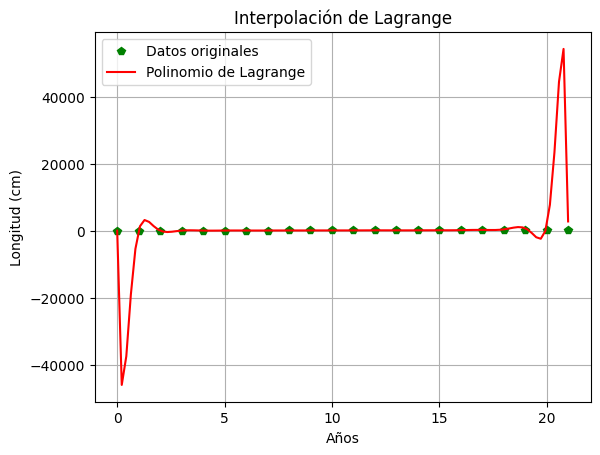

In [103]:
import matplotlib.pyplot as plt

ux = np.linspace(min(anios), max(anios), 100)

plt.plot(anios, longitud, 'gp', label='Datos originales')
plt.plot(ux, polinomio_lagrange(ux), 'r', label='Polinomio de Lagrange')
plt.xlabel('Años')
plt.ylabel('Longitud (cm)')
plt.title('Interpolación de Lagrange')
plt.grid()
plt.legend()

## Item(b)

/tmp/ipykernel_33910/31504852.py:327: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(x_d), y_d, 'ob')
/tmp/ipykernel_33910/31504852.py:339: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(x_d), np.log(y_d), 'ob')


<module 'matplotlib.pyplot' from '/home/felipe/Desktop/5to/Analisis_numerico/venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

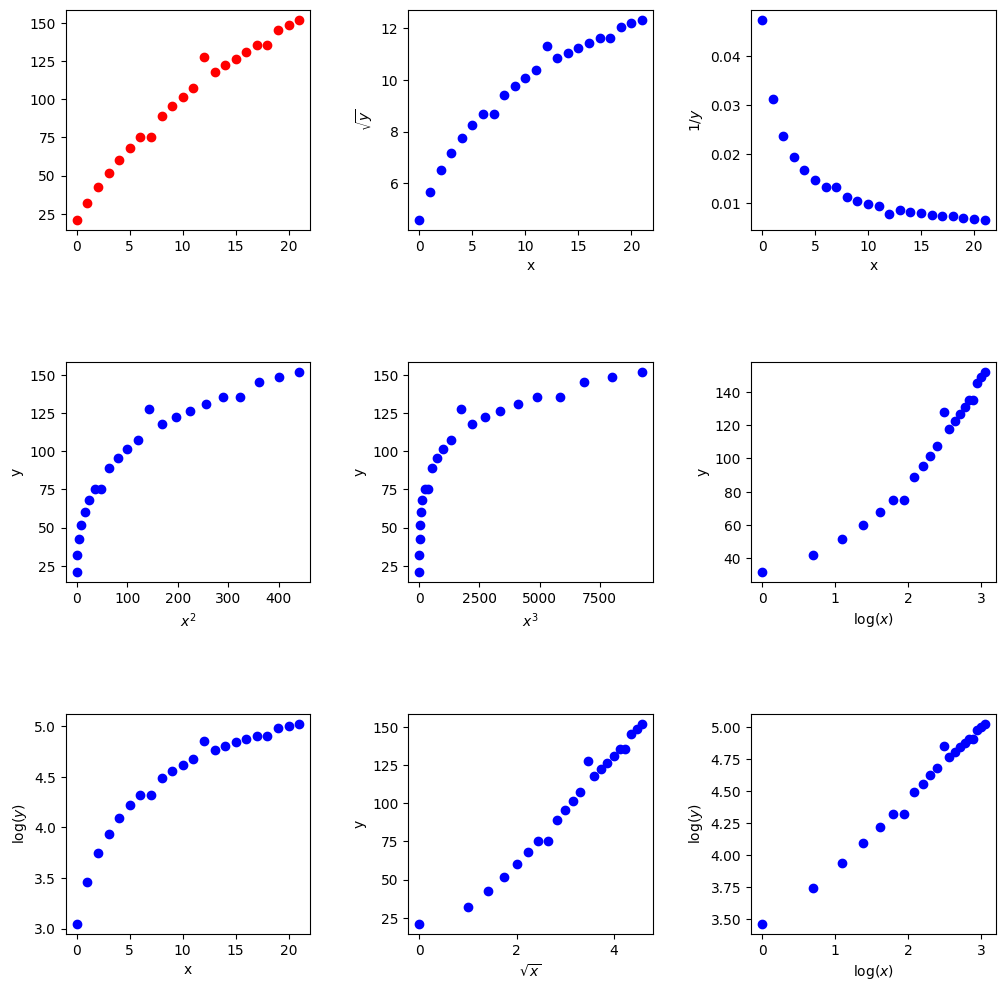

In [104]:

graficar_escalas(anios, longitud)

De acuerdo a lo anterior podemos darnos cuenta que el modelo que más se ajusta es $log(y) log(x)$

a0: 3.6563009295099578, a1: 0.4183023317564882


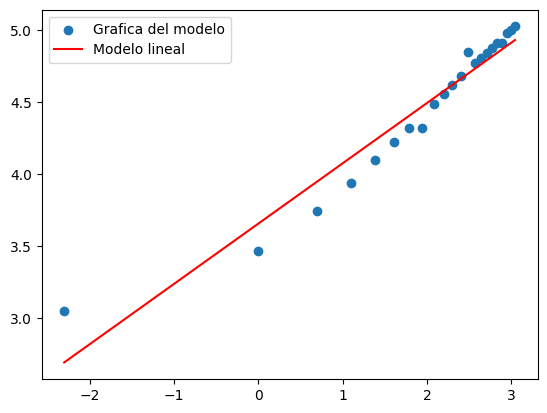

In [105]:

x_data = np.array([0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
y_data = np.array([21.1, 32.0, 42.3, 51.4, 60.1, 68.0, 75.3, 75.3, 89.0, 95.3, 101.6, 107.6, 127.7, 117.7, 122.2, 126.5, 130.9, 135.3, 135.3, 145.0, 148.6, 152.0])

a0, a1 = minimos_cuadrados(np.log(x_data), np.log(y_data))

print(f"a0: {a0}, a1: {a1}")
ux = np.linspace(min(np.log(x_data)), max(np.log(x_data)))
P = lambda x: a0 + a1 * x
plt.scatter(np.log(x_data), np.log(y_data), label='Grafica del modelo')
plt.plot(ux, P(ux),'r', label='Modelo lineal')
plt.legend()

En la gráfica anterior se observa que el modelo si se ajusta, ahora vamos a graficar el modelo con los datos observados

### Graficando el modelo no lineal

### Partir de $Y=a_0+a_1x$, dependiendo de la escala en este caso $log(x), log(y)$ es el modelo no lineal es:

$$log(y) = a_0+a_1log(x)$$
$$y = e^{a_0 + log(x^{a_1})}$$
$$M = e^{a_0}*x^{a_1}$$

Con el polinomio M ya se pueden hacer predicciones para el caso específico

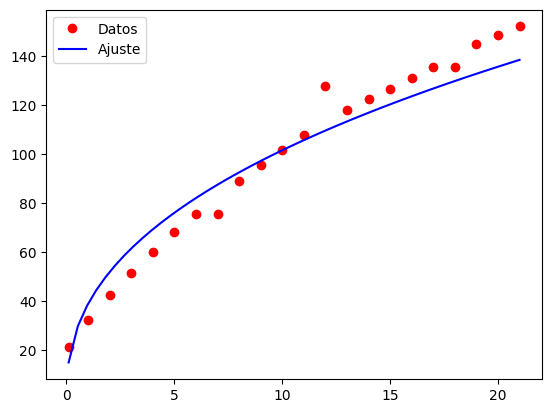

In [106]:
u_x = np.linspace(min(x_data), max(x_data))
M = lambda x: np.exp(a0) * x**a1

plt.plot(x_data,y_data, 'or', label="Datos")
plt.plot(u_x, M(u_x), 'b', label="Ajuste")
plt.legend()

De lo anterior ya podemos predecir más certeramente y resolver el item a continuación:

In [107]:
# Prediccion del estrion t =20.5
prediccion = M(20.5)
print(f"Predicción para t = 20.5: {prediccion} cm")

Predicción para t = 20.5: 136.96859997278457 cm


Se puede ver que es un valor mucho más acertado y acorde con los valores vecinos que presenta la tabla con los datos, así que podemos asegurar que es correcto.